<a href="https://colab.research.google.com/github/quarcs-lab/project2025s-py/blob/master/notebooks/c07_alternative_w_matrices.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" /></a>

This notebook re-evaluates the preferred **Model 4** (conditional Spatial Durbin Model with state fixed effects) under a range of **alternative spatial weight matrices**, as a robustness check on the spillover results reported in the main manuscript. The baseline analysis uses a 6-nearest-neighbor (6NN) row-standardized matrix; here we re-estimate the same model with:

- **4 nearest neighbors** and **8 nearest neighbors** (denser/sparser k-NN graphs);
- **Queen** and **Rook** contiguity (shared-boundary neighbors);
- **Inverse distance** ($w_{ij} \propto 1/d_{ij}$) and **inverse distance squared** ($w_{ij} \propto 1/d_{ij}^2$), applied within a distance band.

All matrices are row-standardized. For each, we report the Direct, Indirect, and Total spatial impacts of initial luminosity (full LeSage–Pace method, with Monte-Carlo standard errors) and the model AIC, alongside the 6NN baseline.

In [ ]:
# Google Colab: install packages not included in the default environment
try:
    import google.colab
    !pip install geopandas libpysal spreg -q
except ImportError:
    pass  # Local environment — packages already installed

## 1. Setup

In [ ]:
# Configuration
import os
import math
import warnings
import urllib.request
from contextlib import redirect_stdout

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from libpysal.weights import KNN, Queen, Rook, DistanceBand
from libpysal.weights.util import attach_islands, min_threshold_distance
from spreg import ML_Lag

warnings.filterwarnings("ignore")
np.random.seed(20250620)

DV   = "light_growth96_10rcr_cap"   # dependent variable: per-capita NTL growth 1996-2010
XKEY = "log_light96_rcr_cap"        # main regressor: initial (log) per-capita NTL, 1996
KEY  = "statedist"                  # 1:1 merge key between geometry and data
N_MC = 10_000                       # Monte-Carlo draws for impact inference
PROJ = 7755                         # EPSG:7755 (India NSF LCC, metres) for distance-based weights

CONTROLS = [
    "suit_mean_snd", "rain_mean_snd", "mala_mean_snd", "temp_mean_snd",
    "rug_mean_snd", "distance", "latitude", "rur_percent96_rcr",
    "log_tot_density_rcr", "sc_percent96", "st_percent96", "workp_percent96",
    "lit_percent96", "higheredu_percent96", "elechh_percent96", "log_puccaroads",
]

RAW = "https://raw.githubusercontent.com/quarcs-lab/project2025s-py/master/data"

In [ ]:
# Load data (local ../data first, else download from the public repo)
def _resolve(fname):
    for cand in (os.path.join("..", "data", fname), os.path.join("data", fname), fname):
        if os.path.exists(cand):
            return cand
    url = "{}/{}".format(RAW, fname)
    print("Downloading {} from {}".format(fname, url))
    urllib.request.urlretrieve(url, fname)
    return fname


gdf = gpd.read_file(_resolve("india520.geojson"))
dta = pd.read_stata(_resolve("india520.dta"))
keep = [KEY, DV, XKEY, "state"] + CONTROLS
m = gdf[[KEY, "geometry"]].merge(dta[keep], on=KEY)
m = gpd.GeoDataFrame(m, geometry="geometry", crs=gdf.crs)
assert len(m) == 520, "expected 520 districts, got {}".format(len(m))

y = m[[DV]].values
fe = pd.get_dummies(m["state"], prefix="st", drop_first=True).astype(float)
# Model 4 design: key regressor + 16 controls + state fixed effects
Xdf4 = pd.concat([m[[XKEY] + CONTROLS], fe], axis=1)
print("Districts: {} | Model 4 regressors (excl. constant): {}".format(len(m), Xdf4.shape[1]))

Districts: 520 | Model 4 regressors (excl. constant): 44


## 2. Build the alternative weight matrices

All weights are row-standardized. k-NN weights use the same lat/lon centroid basis as the baseline 6NN, so that the 6NN row reproduces Table 1. Contiguity islands (Queen: 1, Rook: 2) are attached to their single nearest neighbor. Inverse-distance weights apply $1/d^{p}$ within a **distance band** — the smallest threshold that leaves no district isolated — with centroid distances measured in a metric projection (EPSG:7755). Banding keeps the weights local and avoids the near-collinearity (every row tending to a global average) that destabilizes dense all-pairs distance weights.

In [ ]:
def w_knn(g, k):
    w = KNN.from_dataframe(g, k=k)            # lat/lon centroids, matches the baseline
    w.transform = "r"
    return w


def w_contig(g, kind):
    w = (Queen if kind == "queen" else Rook).from_dataframe(g, use_index=False, silence_warnings=True)
    if w.islands:                              # attach each island to its nearest neighbor
        w = attach_islands(w, KNN.from_dataframe(g, k=1), silence_warnings=True)
    w.transform = "r"
    return w


def w_invdist(g, power):
    cent = g.to_crs(PROJ).geometry.centroid    # metric CRS for accurate distances
    xy = np.c_[cent.x.values, cent.y.values]
    th = min_threshold_distance(xy)            # smallest band that leaves no district isolated
    w = DistanceBand(xy, threshold=th, alpha=-float(power), binary=False, silence_warnings=True)
    w.transform = "r"
    return w


WMATS = [
    ("4 nearest neighbors",       w_knn(m, 4)),
    ("6 nearest neighbors (base)", w_knn(m, 6)),
    ("8 nearest neighbors",       w_knn(m, 8)),
    ("Queen contiguity",          w_contig(m, "queen")),
    ("Rook contiguity",           w_contig(m, "rook")),
    ("Inverse distance",          w_invdist(m, 1)),
    ("Inverse distance squared",  w_invdist(m, 2)),
]
for name, w in WMATS:
    print("{:28s} mean neighbours = {:.2f}".format(name, w.mean_neighbors))

4 nearest neighbors          mean neighbours = 4.00
6 nearest neighbors (base)   mean neighbours = 6.00
8 nearest neighbors          mean neighbours = 8.00
Queen contiguity             mean neighbours = 5.19
Rook contiguity              mean neighbours = 5.05
Inverse distance             mean neighbours = 14.17
Inverse distance squared     mean neighbours = 14.17


## 3. Re-estimate Model 4 under each weight matrix

We reuse the manuscript's estimation logic: a Spatial Durbin Model via `ML_Lag(slx_lags=1)`, with Direct/Indirect/Total impacts of initial luminosity computed by the full (LeSage–Pace) method from the exact spatial multiplier matrix $(I-\rho W)^{-1}$, and Monte-Carlo standard errors.

In [ ]:
def stars(est, se):
    if se <= 0 or not np.isfinite(se):
        return ""
    z = abs(est / se)
    p = 2 * (1 - 0.5 * (1 + math.erf(z / math.sqrt(2))))
    return "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""


def full_rank_lag_mask(Xv, Wd):
    n, k = Xv.shape
    WX = Wd @ Xv
    design = np.hstack([np.ones((n, 1)), Xv])
    rank = np.linalg.matrix_rank(design)
    mask = [True] * k
    for j in range(k):
        test = np.hstack([design, WX[:, [j]]])
        if np.linalg.matrix_rank(test) > rank:
            design, rank = test, rank + 1
        else:
            mask[j] = False
    return mask


def run_sdm(y, Xdf, w):
    """SDM (full LeSage-Pace impacts) of the key regressor for one weight matrix.

    Direct = adi*b, Total = (b+g)/(1-rho), Indirect = Total - Direct, where
    adi = mean diag((I-rho W)^-1) via the eigenvalues of W. Monte-Carlo SEs
    recompute adi for each rho draw.
    """
    Wd = w.full()[0]
    eigs = np.linalg.eigvals(Wd)
    Xv = Xdf.astype(float).values
    mask = full_rank_lag_mask(Xv, Wd)
    slx_vars = "All" if all(mask) else mask
    with redirect_stdout(open(os.devnull, "w")):
        mod = ML_Lag(y=y, x=Xv, w=w, slx_lags=1, slx_vars=slx_vars, spat_impacts="full")

    b = mod.betas.flatten()
    k = Xv.shape[1]
    i_b, i_g, i_r = 1, 1 + k, len(b) - 1
    rho = b[i_r]

    def adi(R):
        R = np.atleast_1d(np.asarray(R, dtype=float))
        return (1.0 / (1.0 - np.outer(R, eigs))).real.mean(axis=1)

    direct = adi(rho)[0] * b[i_b]
    total = (b[i_b] + b[i_g]) / (1 - rho)
    indirect = total - direct

    draws = np.random.multivariate_normal(b, mod.vm, size=N_MC)
    D, G, R = draws[:, i_b], draws[:, i_g], draws[:, i_r]
    Deff = adi(R) * D
    T = (D + G) / (1 - R)
    I = T - Deff
    return {
        "direct": direct, "direct_se": Deff.std(),
        "indirect": indirect, "indirect_se": I.std(),
        "total": total, "total_se": T.std(),
        "aic": mod.aic, "rho": rho,
    }


np.random.seed(20250620)
res = {}
for name, w in WMATS:
    res[name] = run_sdm(y, Xdf4, w)
    print("{:28s} done (rho={:.3f})".format(name, res[name]["rho"]))

4 nearest neighbors          done (rho=0.190)


6 nearest neighbors (base)   done (rho=0.199)


8 nearest neighbors          done (rho=0.162)


Queen contiguity             done (rho=0.227)


Rook contiguity              done (rho=0.231)


Inverse distance             done (rho=-0.002)


Inverse distance squared     done (rho=0.157)


## 4. Robustness table

In [ ]:
#| label: tbl-altw
#| tbl-cap: "Model 4 spatial impacts of initial luminosity under alternative spatial weight matrices (full LeSage–Pace method; Monte-Carlo standard errors in parentheses)."
from IPython.display import Markdown


def _cell(est, se):
    return "{:.3f}{}".format(est, stars(est, se))


rows = [
    "| Weight matrix | Direct | Indirect | Total | AIC |",
    "|---------------|--------|----------|-------|-----|",
]
for name, _ in WMATS:
    r = res[name]
    rows.append("| {} | {}<br>({:.3f}) | {}<br>({:.3f}) | {}<br>({:.3f}) | {:.0f} |".format(
        name,
        _cell(r["direct"], r["direct_se"]), r["direct_se"],
        _cell(r["indirect"], r["indirect_se"]), r["indirect_se"],
        _cell(r["total"], r["total_se"]), r["total_se"],
        r["aic"],
    ))
Markdown("\n".join(rows))

| Weight matrix | Direct | Indirect | Total | AIC |
|---------------|--------|----------|-------|-----|
| 4 nearest neighbors | -0.024***<br>(0.002) | -0.008<br>(0.006) | -0.032***<br>(0.006) | -2468 |
| 6 nearest neighbors (base) | -0.025***<br>(0.002) | -0.013*<br>(0.007) | -0.037***<br>(0.007) | -2501 |
| 8 nearest neighbors | -0.025***<br>(0.002) | -0.011<br>(0.008) | -0.036***<br>(0.008) | -2485 |
| Queen contiguity | -0.025***<br>(0.002) | -0.010**<br>(0.005) | -0.035***<br>(0.005) | -2463 |
| Rook contiguity | -0.025***<br>(0.002) | -0.009**<br>(0.005) | -0.034***<br>(0.005) | -2469 |
| Inverse distance | -0.025***<br>(0.002) | -0.016**<br>(0.007) | -0.041***<br>(0.008) | -2486 |
| Inverse distance squared | -0.025***<br>(0.002) | -0.012*<br>(0.006) | -0.037***<br>(0.006) | -2485 |

## 5. Summary figure

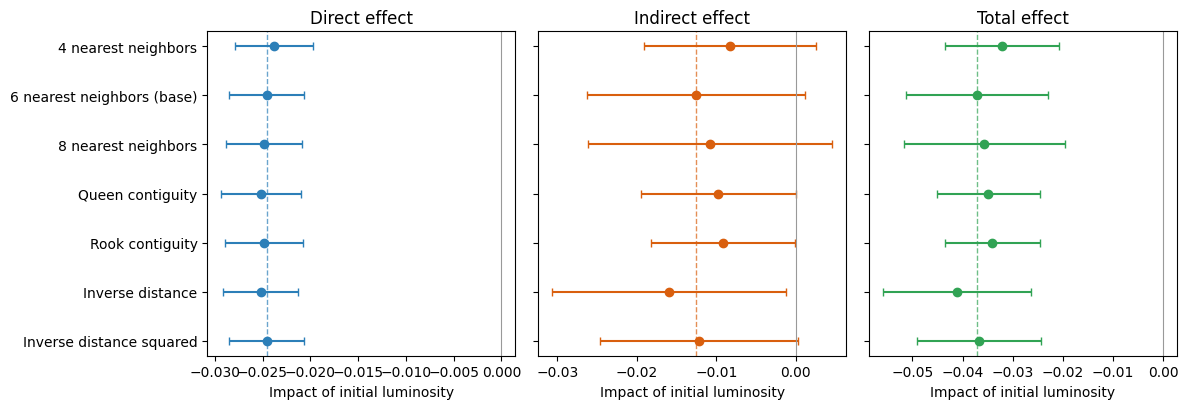

In [ ]:
#| label: fig-altw
#| fig-cap: "Robustness of the Model 4 spatial impacts of initial luminosity to the choice of spatial weight matrix. Points are Direct, Indirect, and Total impacts; bars are 95% Monte-Carlo confidence intervals. The dashed lines mark the 6NN baseline estimates."
names = [n for n, _ in WMATS]
ypos = np.arange(len(names))[::-1]   # top-to-bottom in listed order
effects = [("direct", "Direct", "#2c7fb8"), ("indirect", "Indirect", "#d95f0e"), ("total", "Total", "#31a354")]

fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), sharey=True)
for ax, (key, label, color) in zip(axes, effects):
    est = np.array([res[n][key] for n in names])
    se = np.array([res[n][key + "_se"] for n in names])
    ax.errorbar(est, ypos, xerr=1.96 * se, fmt="o", color=color, ecolor=color,
                elinewidth=1.5, capsize=3, markersize=6)
    ax.axvline(0, color="0.6", lw=0.8)
    base = res["6 nearest neighbors (base)"][key]
    ax.axvline(base, color=color, ls="--", lw=1.0, alpha=0.7)
    ax.set_title("{} effect".format(label))
    ax.set_xlabel("Impact of initial luminosity")
axes[0].set_yticks(ypos)
axes[0].set_yticklabels(names)
fig.tight_layout()
plt.show()

The estimates are reported alongside the 6NN baseline (dashed lines), so the figure shows directly whether the sign, magnitude, and significance of the convergence spillovers are robust to the choice of spatial weight matrix.